# CCPD — Data Exploration

In [2]:
import os, re, sys, glob, math, json, random, pickle
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
random.seed(0); np.random.seed(0)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "font.size": 10})

DATASET_ROOT = Path("Dataset")    
CACHE_PATH   = Path("ccpd_meta.pkl")     
MAX_FILES    = None  # set to e.g. 5000 to subsample for a quick first pass

print("Dataset root:", DATASET_ROOT.resolve())
print("Exists:      ", DATASET_ROOT.exists())

Dataset root: /home/luca/IS_Project/Dataset
Exists:       True


In [3]:
#31 provinces + '警' (police) + '学' (learner) + 'O' (sentinel) = 34
PROVINCES = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
             '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
             '陕','甘','青','宁','新','警','学','O']  # 34

ALPHABETS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
             'P','Q','R','S','T','U','V','W','X','Y','Z','O']  # 25

# Alphanumerics (24 letters + 10 digits + 'O' sentinel = 35)
ADS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
       'P','Q','R','S','T','U','V','W','X','Y','Z',
       '0','1','2','3','4','5','6','7','8','9','O']  # 35

print(f"PROVINCES: {len(PROVINCES)} entries — first 5 = {PROVINCES[:5]}, last = '{PROVINCES[-1]}'")
print(f"ALPHABETS: {len(ALPHABETS)} entries — last is sentinel '{ALPHABETS[-1]}'")
print(f"ADS:       {len(ADS)} entries — last is sentinel '{ADS[-1]}'")

PROVINCES: 34 entries — first 5 = ['皖', '沪', '津', '渝', '冀'], last = 'O'
ALPHABETS: 25 entries — last is sentinel 'O'
ADS:       35 entries — last is sentinel 'O'



A CCPD filename looks like:

```
025-95_113-154&383_386&473-386&473_177&454_154&383_363&402-0_0_22_27_27_33_16-95-9.jpg
```

It has seven fields:

| Field | Example | Meaning |
|---|---|---|
| 1 | `025` | Ratio of the image area occupied by the plate |
| 2 | `95_113` | Tilt degrees: horizontal_vertical |
| 3 | `154&383_386&473` | Bounding box: top-left x&y _ bottom-right x&y |
| 4 | `386&473_177&454_154&383_363&402` | **Four vertices** (x&y each). |
| 5 | `0_0_22_27_27_33_16` | **Plate label**: 7 indices |
| 6 | `95` | Brightness |
| 7 | `9` | Blur |


In [4]:

_FNAME_FIELDS = 7

def parse_ccpd_filename(path):
    """Decode a CCPD filename into a dict of all annotations.
    Returns None on any parsing failure (so callers can skip bad files).
    """
    name = Path(path).stem 
    fields = name.split('-')
    if len(fields) != _FNAME_FIELDS:
        return None

    f_area, f_tilt, f_bbox, f_verts, f_label, f_bright, f_blur = fields

    try:
        area_ratio = int(f_area) / 1000.0

        tilt_h, tilt_v = map(int, f_tilt.split('_'))

        (x1, y1), (x2, y2) = [tuple(map(int, p.split('&'))) for p in f_bbox.split('_')]

        verts = [tuple(map(int, p.split('&'))) for p in f_verts.split('_')]
        if len(verts) != 4: return None

        idxs = list(map(int, f_label.split('_')))
        if len(idxs) != 7: return None
        plate = (
            PROVINCES[idxs[0]] +
            ALPHABETS[idxs[1]] +
            ''.join(ADS[i] for i in idxs[2:])
        )

        brightness = int(f_bright)
        blur       = int(f_blur)
    except (ValueError, IndexError):
        return None

    return {
        "path"       : str(path),
        "area_ratio" : area_ratio,
        "tilt_h"     : tilt_h,
        "tilt_v"     : tilt_v,
        "bbox"       : (x1, y1, x2, y2),
        "vertices"   : verts,
        "label_idxs" : idxs,
        "plate"      : plate,
        "brightness" : brightness,
        "blur"       : blur,
    }


# Quick sanity test
_test = "025-95_113-154&383_386&473-386&473_177&454_154&383_363&402-0_0_22_27_27_33_16-95-9.jpg"
print(json.dumps(parse_ccpd_filename(_test), default=str, ensure_ascii=False, indent=2))

{
  "path": "025-95_113-154&383_386&473-386&473_177&454_154&383_363&402-0_0_22_27_27_33_16-95-9.jpg",
  "area_ratio": 0.025,
  "tilt_h": 95,
  "tilt_v": 113,
  "bbox": [
    154,
    383,
    386,
    473
  ],
  "vertices": [
    [
      386,
      473
    ],
    [
      177,
      454
    ],
    [
      154,
      383
    ],
    [
      363,
      402
    ]
  ],
  "label_idxs": [
    0,
    0,
    22,
    27,
    27,
    33,
    16
  ],
  "plate": "皖AY339S",
  "brightness": 95,
  "blur": 9
}


## 4. Walk the dataset and build the metadata dataframe

This walks every `.jpg` under `DATASET_ROOT`, parses its filename, and assembles a single dataframe with one row per image. We also record which sub-folder (i.e. which CCPD subset) each image came from.

Parsing is fast (no image reads), but on the full 250k CCPD it still takes a minute or two. We cache the result so this only happens once.

In [5]:
def discover_subset(p: Path) -> str:
    try:
        rel = p.relative_to(DATASET_ROOT)
        parts = rel.parts
        return parts[0] if len(parts) > 1 else "unknown"
    except ValueError:
        return "unknown"


def build_metadata(root: Path, max_files=None, verbose=True):
    rows, skipped = [], 0
    paths = sorted(root.rglob("*.jpg"))
    if max_files:
        paths = paths[:max_files]
    n = len(paths)
    if verbose: print(f"Found {n:,} .jpg files under {root}")
    for i, p in enumerate(paths, 1):
        rec = parse_ccpd_filename(p)
        if rec is None:
            skipped += 1
            continue
        rec["subset"] = discover_subset(p)
        rows.append(rec)
        if verbose and i % 25000 == 0:
            print(f"  parsed {i:,} / {n:,} ({skipped} skipped)")
    df = pd.DataFrame(rows)
    if verbose:
        print(f"Done. {len(df):,} rows, {skipped} skipped.")
    return df


if CACHE_PATH.exists():
    print(f"Loading cached metadata from {CACHE_PATH} …")
    df = pd.read_pickle(CACHE_PATH)
else:
    df = build_metadata(DATASET_ROOT, max_files=MAX_FILES)
    df.to_pickle(CACHE_PATH)
    print(f"Cached to {CACHE_PATH}")

# Derived columns useful for plots
df["w"]   = df["bbox"].map(lambda b: b[2] - b[0])
df["h"]   = df["bbox"].map(lambda b: b[3] - b[1])
df["aspect"] = df["w"] / df["h"].clip(lower=1)
df["province"] = df["plate"].str[0]
df["letter"]   = df["plate"].str[1]
df["len_ok"]   = df["plate"].str.len() == 7

print(f"\nDataframe: {len(df):,} rows × {len(df.columns)} cols")
df.head(3)

Found 355,013 .jpg files under Dataset
  parsed 25,000 / 355,013 (0 skipped)
  parsed 50,000 / 355,013 (0 skipped)
  parsed 75,000 / 355,013 (0 skipped)
  parsed 100,000 / 355,013 (0 skipped)
  parsed 125,000 / 355,013 (0 skipped)
  parsed 150,000 / 355,013 (0 skipped)
  parsed 175,000 / 355,013 (0 skipped)
  parsed 200,000 / 355,013 (0 skipped)
  parsed 225,000 / 355,013 (0 skipped)
  parsed 250,000 / 355,013 (0 skipped)
  parsed 275,000 / 355,013 (0 skipped)
  parsed 300,000 / 355,013 (0 skipped)
  parsed 325,000 / 355,013 (3036 skipped)
  parsed 350,000 / 355,013 (3036 skipped)
Done. 351,977 rows, 3036 skipped.
Cached to ccpd_meta.pkl

Dataframe: 351,977 rows × 17 cols


,path,area_ratio,tilt_h,tilt_v,bbox,vertices,label_idxs,plate,brightness,blur,subset,w,h,aspect,province,letter,len_ok
0,Dataset/ccpd_base/00205459770115-90_85-352&516...,2.054598e+08,90,85,"(352, 516, 448, 547)","[(444, 547), (368, 549), (364, 517), (440, 515)]","[0, 0, 22, 10, 26, 29, 24]",皖AYL250,128,7,ccpd_base,96,31,3.096774,皖,A,True
1,Dataset/ccpd_base/00221264367816-91_91-283&519...,2.212644e+08,91,91,"(283, 519, 381, 553)","[(375, 551), (280, 552), (285, 514), (380, 513)]","[0, 0, 7, 26, 17, 33, 29]",皖AH2T95,95,9,ccpd_base,98,34,2.882353,皖,A,True
2,Dataset/ccpd_base/00223060344828-90_89-441&517...,2.230603e+08,90,89,"(441, 517, 538, 546)","[(530, 552), (447, 548), (447, 512), (530, 516)]","[0, 0, 13, 16, 33, 30, 33]",皖APS969,148,14,ccpd_base,97,29,3.344828,皖,A,True


subset
ccpd_base         199996
ccpd_challenge     50003
ccpd_tilt          30216
ccpd_fn            20967
ccpd_blur          20611
ccpd_db            10132
ccpd_rotate        10053
ccpd_weather        9999


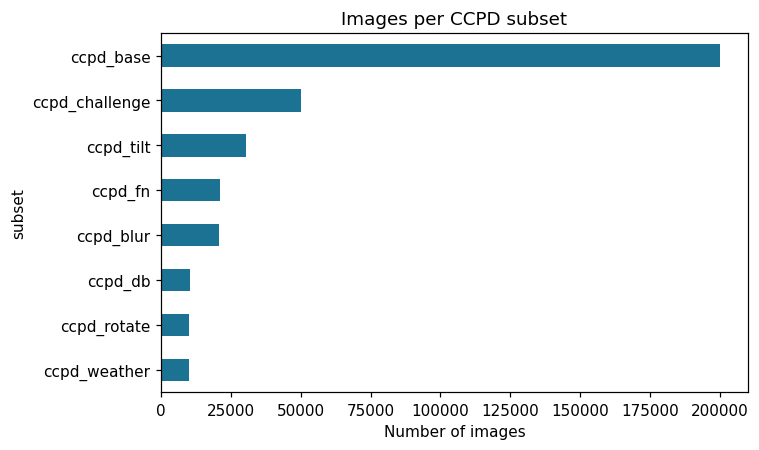

In [6]:
subset_counts = df["subset"].value_counts()
print(subset_counts.to_string())

ax = subset_counts.plot(kind="barh", figsize=(7, 0.4*len(subset_counts)+1), color="#1C7293")
ax.set_xlabel("Number of images")
ax.set_title("Images per CCPD subset")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

/tmp/ipykernel_10881/3876319367.py:22: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10881/3876319367.py:22: UserWarning: Glyph 33487 (\N{CJK UNIFIED IDEOGRAPH-82CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10881/3876319367.py:22: UserWarning: Glyph 27993 (\N{CJK UNIFIED IDEOGRAPH-6D59}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10881/3876319367.py:22: UserWarning: Glyph 27818 (\N{CJK UNIFIED IDEOGRAPH-6CAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10881/3876319367.py:22: UserWarning: Glyph 35947 (\N{CJK UNIFIED IDEOGRAPH-8C6B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10881/3876319367.py:22: UserWarning: Glyph 31908 (\N{CJK UNIFIED IDEOGRAPH-7CA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1

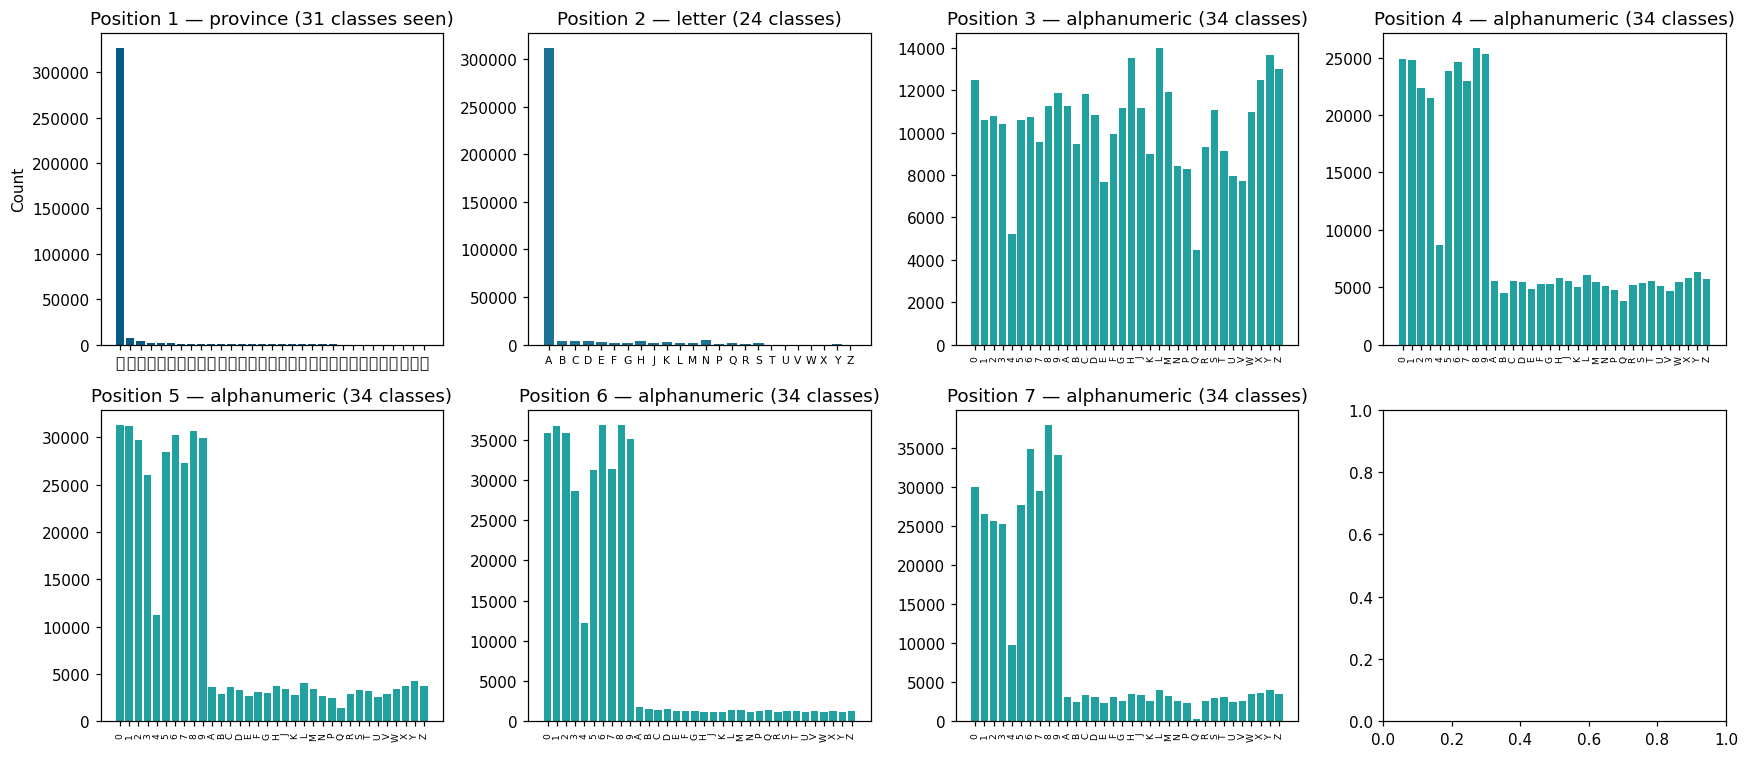

Position-1 top  5: {'皖': 326570, '苏': 7697, '浙': 3565, '沪': 1612, '豫': 1425}
Position-1 tail 5: {'吉': 27, '青': 15, '琼': 14, '宁': 8, '藏': 1}


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

pos1 = df["plate"].str[0].value_counts()
axes[0,0].bar(range(len(pos1)), pos1.values, color="#065A82")
axes[0,0].set_xticks(range(len(pos1))); axes[0,0].set_xticklabels(pos1.index, rotation=0)
axes[0,0].set_title(f"Position 1 — province ({len(pos1)} classes seen)")
axes[0,0].set_ylabel("Count")

pos2 = df["plate"].str[1].value_counts().sort_index()
axes[0,1].bar(range(len(pos2)), pos2.values, color="#1C7293")
axes[0,1].set_xticks(range(len(pos2))); axes[0,1].set_xticklabels(pos2.index, rotation=0, fontsize=7)
axes[0,1].set_title(f"Position 2 — letter ({len(pos2)} classes)")

for k, pos in enumerate([3,4,5,6,7]):
    i = (k+2) // 4
    j = (k+2) % 4
    s = df["plate"].str[pos-1].value_counts().sort_index()
    axes[i,j].bar(range(len(s)), s.values, color="#21A0A0")
    axes[i,j].set_xticks(range(len(s))); axes[i,j].set_xticklabels(s.index, rotation=90, fontsize=6)
    axes[i,j].set_title(f"Position {pos} — alphanumeric ({len(s)} classes)")

plt.tight_layout(); plt.show()

print("Position-1 top  5:", pos1.head(5).to_dict())
print("Position-1 tail 5:", pos1.tail(5).to_dict())

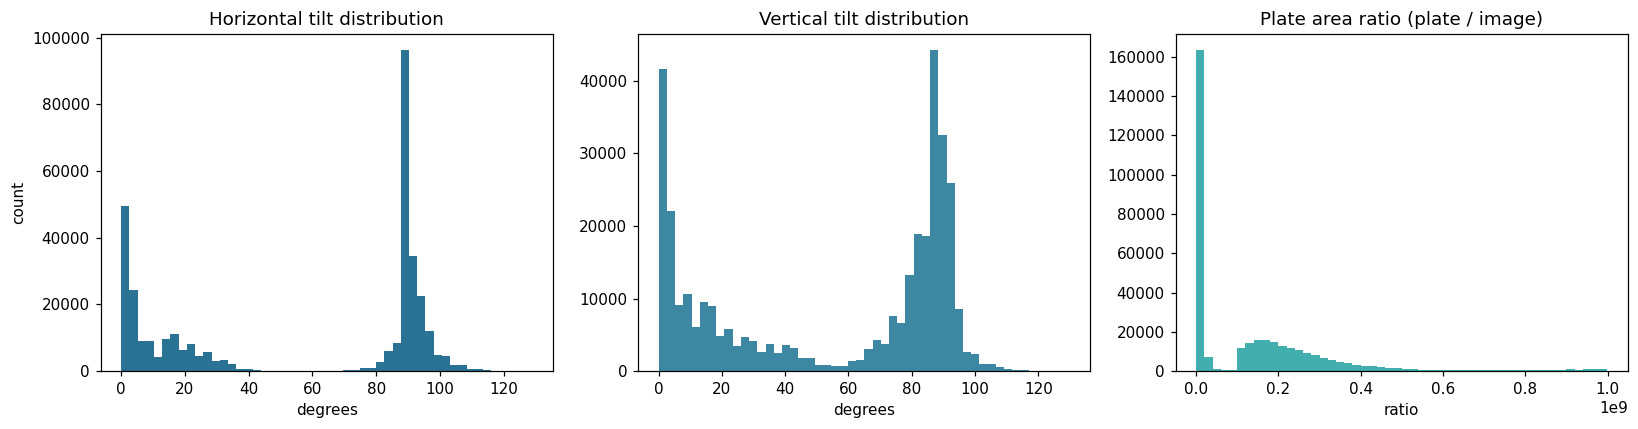


Median tilt by subset:
                tilt_h  tilt_v
subset                        
ccpd_base         90.0    87.0
ccpd_blur          2.0     5.0
ccpd_challenge     3.0     3.0
ccpd_db            3.0     9.0
ccpd_fn            5.0     9.0
ccpd_rotate       22.0    12.0
ccpd_tilt         21.0    31.0
ccpd_weather       2.0     4.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["tilt_h"], bins=50, color="#065A82", alpha=0.85)
axes[0].set_title("Horizontal tilt distribution"); axes[0].set_xlabel("degrees"); axes[0].set_ylabel("count")

axes[1].hist(df["tilt_v"], bins=50, color="#1C7293", alpha=0.85)
axes[1].set_title("Vertical tilt distribution"); axes[1].set_xlabel("degrees")

axes[2].hist(df["area_ratio"], bins=50, color="#21A0A0", alpha=0.85)
axes[2].set_title("Plate area ratio (plate / image)"); axes[2].set_xlabel("ratio")

plt.tight_layout(); plt.show()

if df["subset"].nunique() > 1:
    print("\nMedian tilt by subset:")
    print(df.groupby("subset")[["tilt_h","tilt_v"]].median().sort_index())

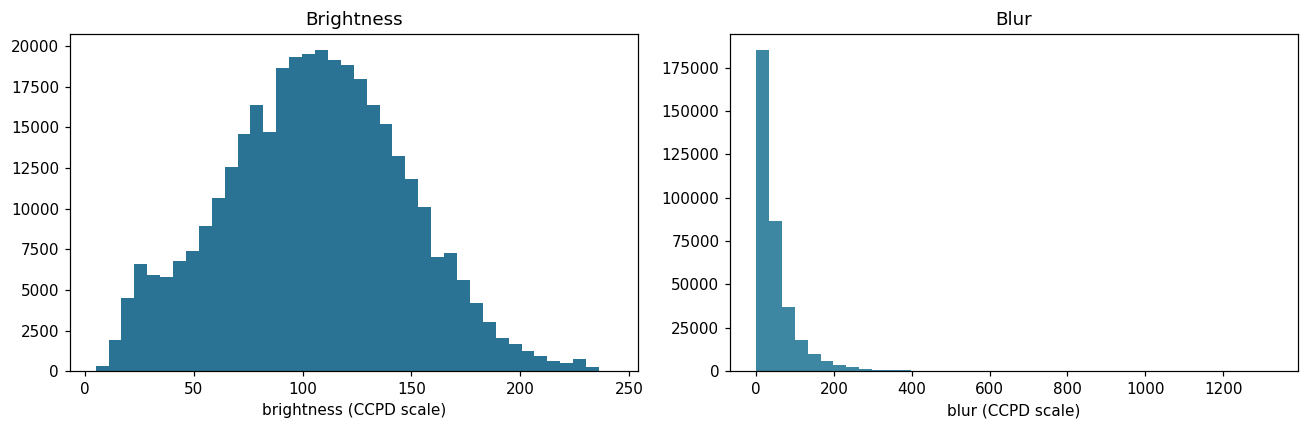


Median brightness / blur by subset:
                brightness  blur
subset                          
ccpd_base            113.0  37.0
ccpd_blur             76.0   4.0
ccpd_challenge       105.0  12.0
ccpd_db               28.0  11.0
ccpd_fn              101.0  33.0
ccpd_rotate          115.0  68.0
ccpd_tilt             95.0  76.0
ccpd_weather          80.0  41.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["brightness"], bins=40, color="#065A82", alpha=0.85)
axes[0].set_title("Brightness"); axes[0].set_xlabel("brightness (CCPD scale)")

axes[1].hist(df["blur"], bins=40, color="#1C7293", alpha=0.85)
axes[1].set_title("Blur"); axes[1].set_xlabel("blur (CCPD scale)")

plt.tight_layout(); plt.show()

if df["subset"].nunique() > 1:
    print("\nMedian brightness / blur by subset:")
    print(df.groupby("subset")[["brightness","blur"]].median().sort_index())

/tmp/ipykernel_94435/2593539097.py:25: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/lucag/IS_Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


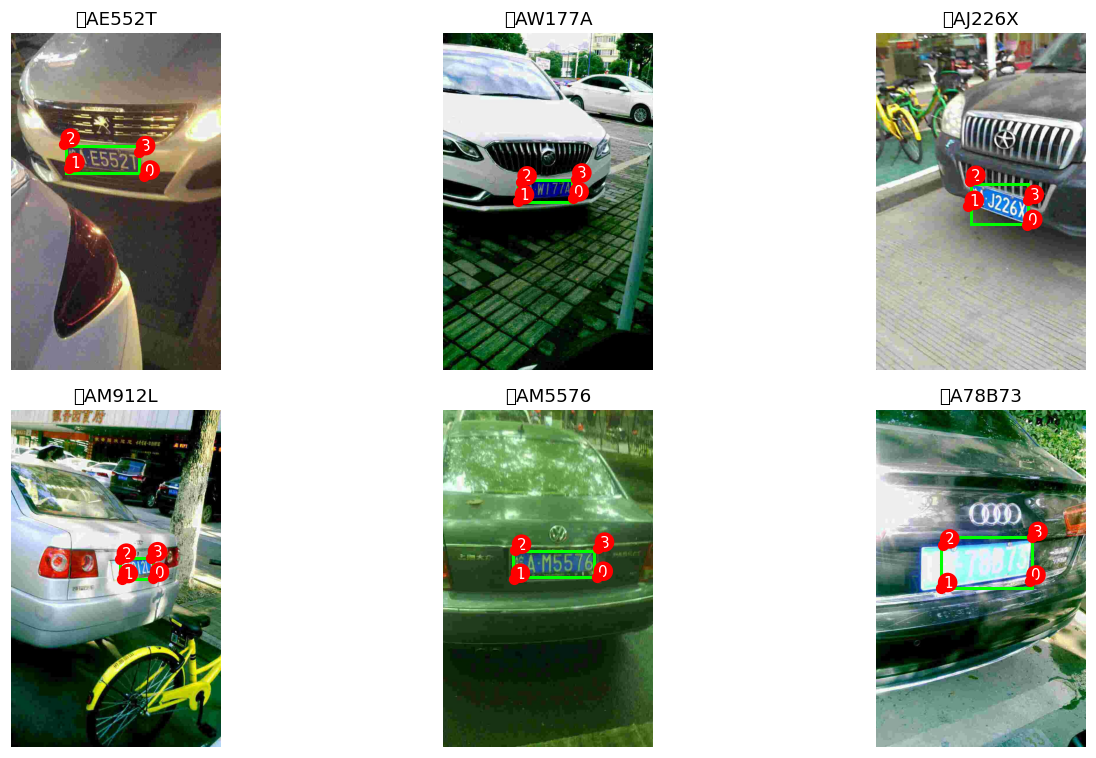

In [12]:
def show_samples(df, n=6, subset=None, seed=0):
    pool = df if subset is None else df[df["subset"] == subset]
    if len(pool) == 0:
        print(f"No images in subset='{subset}'"); return
    sample = pool.sample(min(n, len(pool)), random_state=seed)

    cols = 3
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3.5))
    axes = np.array(axes).reshape(-1)

    for ax, (_, r) in zip(axes, sample.iterrows()):
        img = Image.open(r["path"]).convert("RGB")
        ax.imshow(img)
        x1, y1, x2, y2 = r["bbox"]
        ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="lime", lw=2))
        for i, (x, y) in enumerate(r["vertices"]):
            ax.scatter([x], [y], c="red", s=40, zorder=5)
            ax.text(x+5, y-5, str(i), color="white", fontsize=10,
                    bbox=dict(boxstyle="circle,pad=0.15", fc="red", ec="none"))
        ax.set_title(r["plate"], fontsize=12)
        ax.axis("off")

    for ax in axes[len(sample):]: ax.axis("off")
    plt.tight_layout(); plt.show()

show_samples(df, n=6)

/tmp/ipykernel_94435/2792717133.py:33: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_94435/2792717133.py:33: UserWarning: Glyph 38397 (\N{CJK UNIFIED IDEOGRAPH-95FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_94435/2792717133.py:33: UserWarning: Glyph 27818 (\N{CJK UNIFIED IDEOGRAPH-6CAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/lucag/IS_Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lucag/IS_Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38397 (\N{CJK UNIFIED IDEOGRAPH-95FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lucag/IS_Project/.venv/lib/python3.12/site-packages/IP

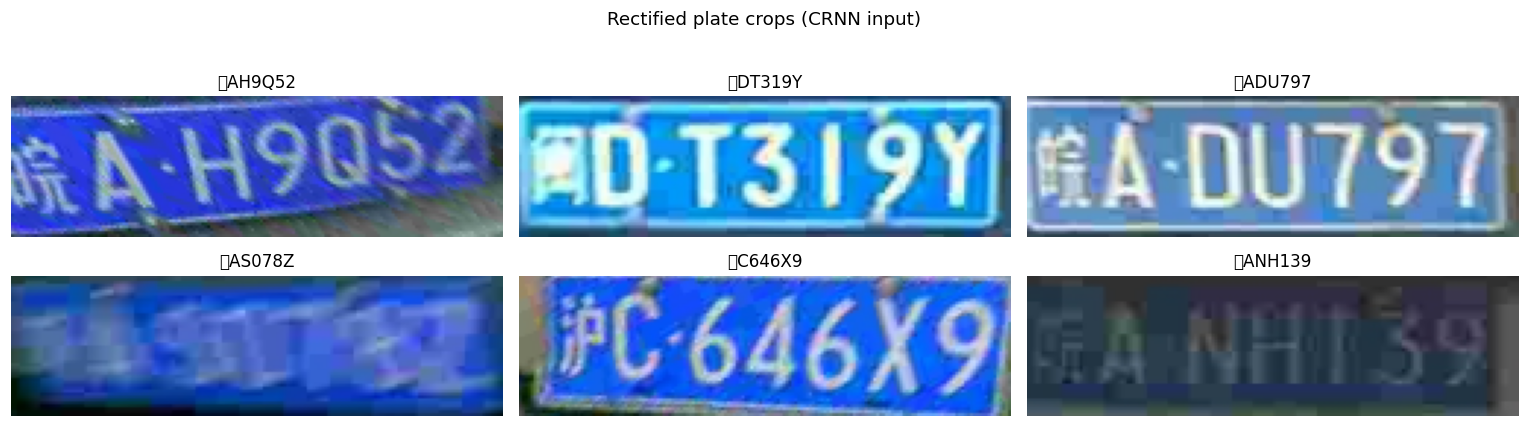

In [ ]:
def rectify_plate(img_bgr, vertices, out_w=168, out_h=48, order="ccpd"):
    """Warp the plate quadrilateral to a fixed-size upright rectangle.

    """
    pts = np.asarray(vertices, dtype=np.float32)
    if order == "ccpd":
        rb, lb, lt, rt = pts
        src = np.stack([lt, rt, rb, lb]).astype(np.float32)
    else:
        src = pts
    dst = np.array([[0,0],[out_w-1,0],[out_w-1,out_h-1],[0,out_h-1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img_bgr, M, (out_w, out_h))


sample = df.sample(6, random_state=1)
fig, axes = plt.subplots(2, 3, figsize=(14, 4))
for ax, (_, r) in zip(axes.ravel(), sample.iterrows()):
    img_bgr = cv2.imread(r["path"])
    if img_bgr is None:
        ax.set_title("(failed to read)"); ax.axis("off"); continue
    warped = rectify_plate(img_bgr, r["vertices"])
    ax.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    ax.set_title(r["plate"], fontsize=11)
    ax.axis("off")
plt.suptitle("Rectified plate crops (CRNN input)", y=1.02)
plt.tight_layout(); plt.show()


In [ ]:
summary = df.groupby("subset").agg(
    n          = ("plate", "size"),
    tilt_h_med = ("tilt_h",     "median"),
    tilt_v_med = ("tilt_v",     "median"),
    bright_med = ("brightness", "median"),
    blur_med   = ("blur",       "median"),
    area_med   = ("area_ratio", "median"),
).sort_index()
display(summary)


,n,tilt_h_med,tilt_v_med,bright_med,blur_med,area_med
subset,,,,,,
ccpd_base,199996,90.0,87.0,113.0,37.0,2.098420e+08
ccpd_blur,20611,2.0,5.0,76.0,4.0,2.520000e-01
ccpd_challenge,50003,3.0,3.0,105.0,12.0,1.810000e-01
ccpd_db,10132,3.0,9.0,28.0,11.0,3.570000e-01
ccpd_fn,20967,5.0,9.0,101.0,33.0,7.580000e-01
ccpd_rotate,10053,22.0,12.0,115.0,68.0,4.240000e-01
ccpd_tilt,30216,21.0,31.0,95.0,76.0,4.640000e-01
ccpd_weather,9999,2.0,4.0,80.0,41.0,3.250000e-01


In [15]:
# 1. All plates should be exactly 7 characters
bad_len = df[~df["len_ok"]]
print(f"Plates with non-7 length: {len(bad_len)} (should be 0)")

# 2. The sentinel 'O' should be rare or absent in decoded plate strings
sentinel_hits = df["plate"].str.contains("O", regex=False).sum()
print(f"Plates containing sentinel 'O':   {sentinel_hits} (should be ~0 — investigate if many)")

# 3. Bounding box sanity
bad_box = df[(df["w"] <= 0) | (df["h"] <= 0)]
print(f"Plates with non-positive bbox:    {len(bad_box)} (should be 0)")

# 4. Duplicate filenames?
dups = df["path"].duplicated().sum()
print(f"Duplicate paths:                  {dups} (should be 0)")

# 5. Province coverage — how many province classes are seen?
seen = df["province"].nunique()
print(f"Province classes seen: {seen} (max 33 real: 31 provinces + 警 + 学; CCPD is dominated by 皖, small subsets often show only 1–3)")

Plates with non-7 length: 0 (should be 0)
Plates containing sentinel 'O':   0 (should be ~0 — investigate if many)
Plates with non-positive bbox:    0 (should be 0)
Duplicate paths:                  0 (should be 0)
Province classes seen: 31 (max 33 real: 31 provinces + 警 + 学; CCPD is dominated by 皖, small subsets often show only 1–3)
